# Customer Churn Analysis – Telecom Dataset

Notebook desenvolvido para o Trabalho Final da disciplina de Fundamentos de Machine Learning.

Objetivo: análise exploratória, processamento dos dados, modelagem, avaliação, tuning e interpretabilidade para prever churn de clientes.


## 1. Introdução

Customer Churn ocorre quando clientes deixam de utilizar os serviços de uma empresa.

**Objetivos do Projeto**:
- Analisar o perfil dos clientes e identificar padrões associados ao churn.
- Explorar as variáveis que mais influenciam o cancelamento.
- Construir modelos preditivos e comparar desempenho.
- Gerar insights úteis tanto para público técnico quanto de negócio.

**Resumo do Dataset**: descreva brevemente o conjunto de dados (ex.: número de amostras, variáveis, fonte).

## 2. Importando Bibliotecas e Carregando os Dados

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import shap

df = pd.read_csv('churn.csv')


## 3. Entendendo o Conjunto de Dados

In [65]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Transformação do tipo de variáveis para analises exploratorias

In [66]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [67]:
cat_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

In [68]:
df.encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [69]:
df.encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   SeniorCitizen                          7043 non-null   int64  
 2   tenure                                 7043 non-null   int64  
 3   MonthlyCharges                         7043 non-null   float64
 4   TotalCharges                           7032 non-null   float64
 5   Churn                                  7043 non-null   object 
 6   gender_Male                            7043 non-null   bool   
 7   Partner_Yes                            7043 non-null   bool   
 8   Dependents_Yes                         7043 non-null   bool   
 9   PhoneService_Yes                       7043 non-null   bool   
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [70]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


## 4. Verificando e Tratando Valores Ausentes

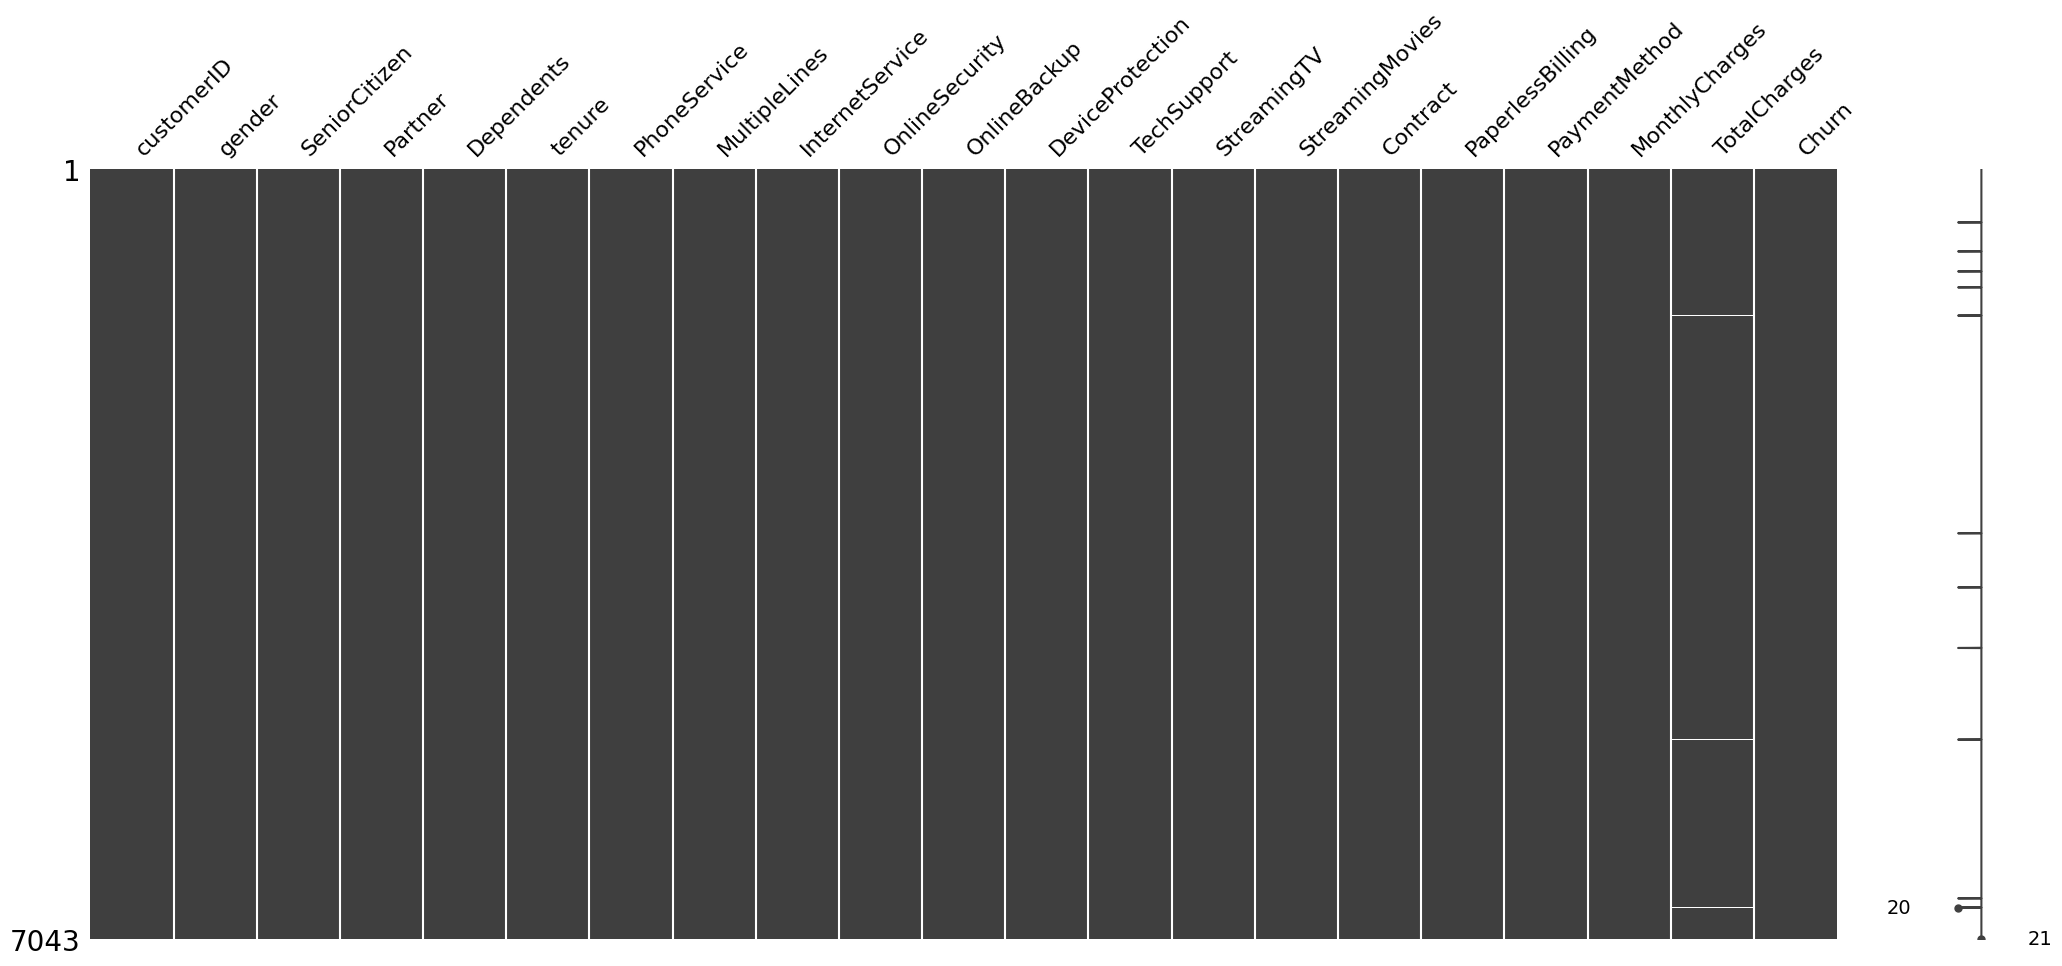

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [71]:
# Visualizar padrão de valores ausentes
msno.matrix(df)
plt.show()

# Converter TotalCharges para numérico (alguns valores vêm como string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remover linhas com valores ausentes resultantes da conversão
df = df.dropna()

# Verificar se ainda há valores ausentes
df.isnull().sum()

## 5. Processamento dos Dados

In [72]:
# --- Limpeza inicial ---
df.drop('customerID', axis=1, inplace=True)

# Transformando SeniorCitizen em variável categórica
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# --- Codificação de variáveis categóricas ---
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Exibindo primeiras linhas após o processamento
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 6. Análise Exploratória de Dados (EDA)

#### Iniciamos através da análise de distribuição de churn, seguido de uma matrix geral de correlação. O objetivo é ter a visão geral do cenario.

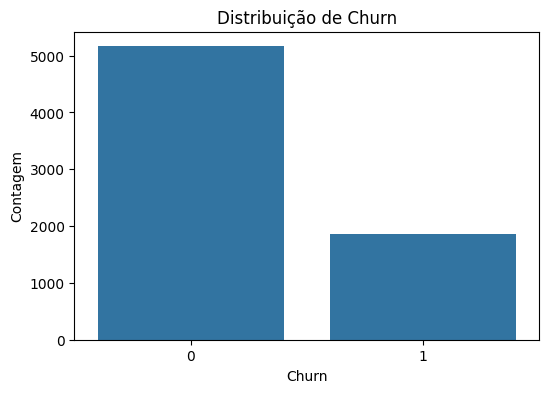

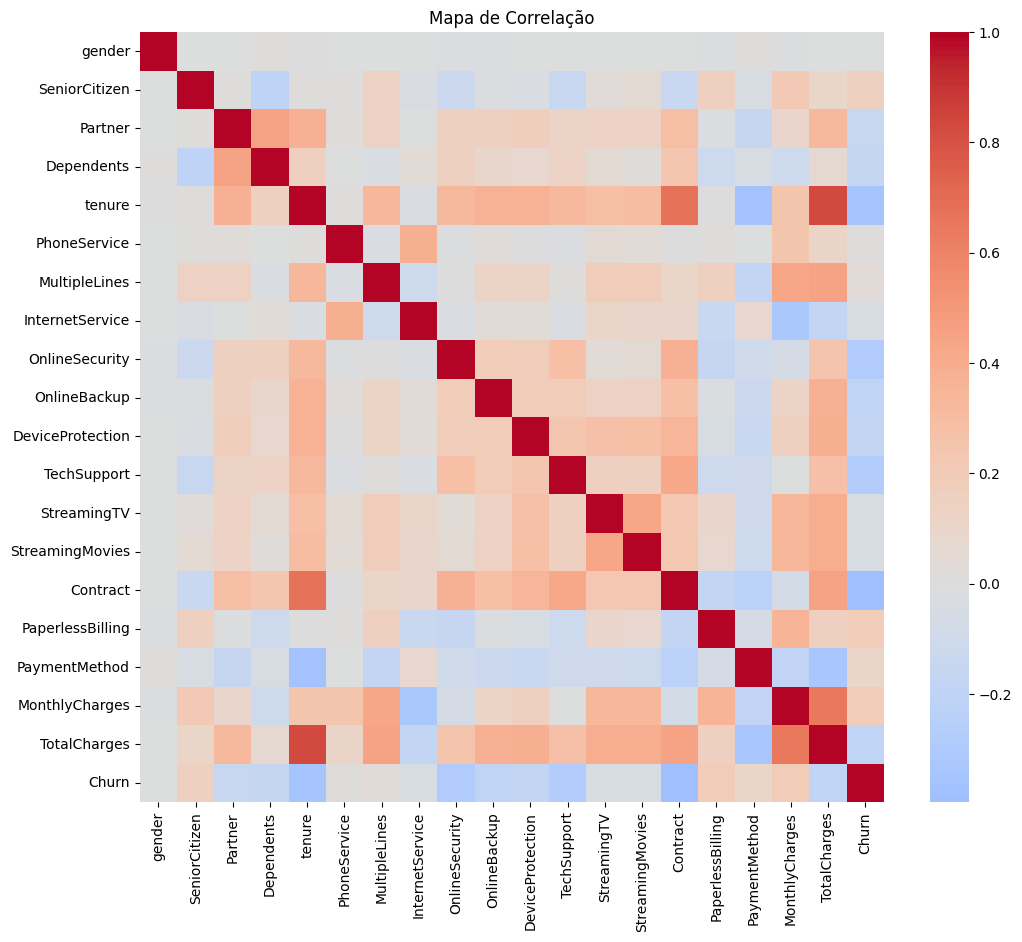

In [73]:
# --- Distribuição de Churn ---
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Contagem')
plt.show()

# --- Matriz de Correlação ---
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Mapa de Correlação')
plt.show()


### Na sequência, com base nas colunas do dataset, avaliamos as seguintes correlações:

##### 1. Custo médio mensal por serviço de internet - Qual serviço de internet (DSL, Fibra) tem o maior custo mensal médio? (Ajuda a entender a estrutura de preços).
##### 2. Taxa de Churn (%) entre Clientes Seniores vs. Não Seniores - Existe diferença na taxa de cancelamento entre clientes seniores (SeniorCitizen=1) e clientes mais jovens? (Foca no segmento etário).
##### 3. Taxa de Churn por tipo de contrato - A correlação bivariada entre Tempo Médio de Permanência (Tenure) e Tipo de Serviço de Internet revela uma contradição crucial na experiência do cliente com o serviço de Fibra Ótica.
##### 4. Proporção de Suporte Técnico por Contratação de Segurança Online - Clientes que contratam segurança online também tendem a contratar suporte técnico? (Revela pacotes de serviços e clientes que valorizam a segurança/assistência).
##### 5. Tempo Médio de Permanência por Tipo de Internet Service - A correlação revela que o Tempo Médio de Permanência não é um fator de diferenciação entre as tecnologias DSL e Fibra Ótica. Em vez disso, a correlação aponta para um problema de satisfação concentrado no início do ciclo de vida do cliente de Fibra Ótica.

In [74]:
def analise_custo_servico(caminho_arquivo):
    df = pd.read_csv(caminho_arquivo)

    # Garantir que MonthlyCharges é numérico
    df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
    df = df.dropna(subset=['MonthlyCharges', 'InternetService'])

    # CÁLCULO RESUMIDO
    # Agrupar por InternetService e calcular a média das Cobranças Mensais
    avg_charges = df.groupby('InternetService')['MonthlyCharges'].mean().sort_values(ascending=False)

    # IMPRIMIR O CÁLCULO DENTRO DO PRINT (USANDO TO_STRING)
    print("\n--- Média de Cobrança Mensal por Serviço de Internet ---")
    print(avg_charges.to_string(header=False, float_format='%.2f'))

    # VISUALIZAÇÃO (Gráfico de Barras é o melhor para comparar médias categóricas)
    plt.figure(figsize=(8, 5))
    ax = avg_charges.plot(kind='bar', color=sns.color_palette("viridis", len(avg_charges)))

    plt.title('Custo Mensal Médio por Serviço de Internet')
    plt.ylabel('Cobrança Mensal Média')
    plt.xlabel('Serviço de Internet')
    plt.xticks(rotation=0)

    # Adicionar valor no topo das barras
    for index, value in enumerate(avg_charges):
        plt.text(index, value + 1, f'{value:.2f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('analise_3_custo_servico.png')
    plt.show()

    print("\n✅ Gráfico de barras (o melhor para esta comparação) salvo em 'analise_3_custo_servico.png'.")



--- Taxa de Churn por Status de Senior Citizen ---
SeniorCitizen
0   23.6
1   41.7


<Figure size 700x500 with 0 Axes>

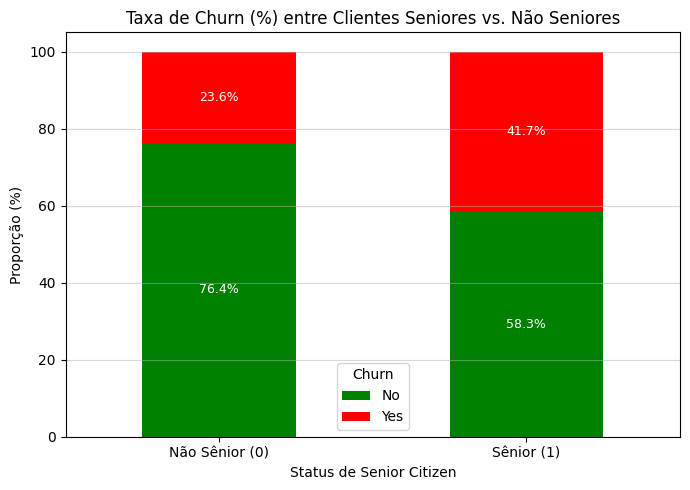


✅ Gráfico de barras empilhadas (ideal para esta proporção) salvo em 'analise_4_senior_churn.png'.


In [75]:
def analise_senior_churn(caminho_arquivo):
    df = pd.read_csv(caminho_arquivo)

    # 1. Pré-processamento e Limpeza (Garantir colunas corretas)
    df = df.dropna(subset=['SeniorCitizen', 'Churn'])

    # 2. CÁLCULO DE PROPORÇÃO RESUMIDO
    # Cria a tabela de contingência e normaliza por índice (linha) para obter a % de Churn DENTRO de cada grupo SeniorCitizen.
    churn_rate_by_senior = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

    # Extrai o resultado para impressão
    churn_rate_yes = churn_rate_by_senior['Yes']

    # IMPRIMIR O CÁLCULO DENTRO DO PRINT (USANDO TO_STRING)
    print("\n--- Taxa de Churn por Status de Senior Citizen ---")
    print(churn_rate_yes.to_string(float_format='%.1f'))

    # VISUALIZAÇÃO (Melhor gráfico: Barras Empilhadas)
    plt.figure(figsize=(7, 5))

    # Mapear o índice 0/1 para labels para o plot
    churn_rate_by_senior.index = ['Não Sênior (0)', 'Sênior (1)']

    ax = churn_rate_by_senior.plot(
        kind='bar', stacked=True,
        figsize=(7, 5),
        color=['green', 'red'] # Cores para No/Yes
    )

    plt.title('Taxa de Churn (%) entre Clientes Seniores vs. Não Seniores')
    plt.xlabel('Status de Senior Citizen')
    plt.ylabel('Proporção (%)')
    plt.xticks(rotation=0)
    plt.legend(title='Churn', labels=['No', 'Yes'])
    plt.grid(axis='y', alpha=0.5)

    # Adicionar porcentagens nas barras
    for c in ax.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white')

    plt.tight_layout()
    plt.savefig('analise_4_senior_churn.png')
    plt.show()

    print("\n✅ Gráfico de barras empilhadas (ideal para esta proporção) salvo em 'analise_4_senior_churn.png'.")

analise_senior_churn('churn.csv')

Churn             0          1
Contract                      
0         57.290323  42.709677
1         88.722826  11.277174
2         97.151335   2.848665


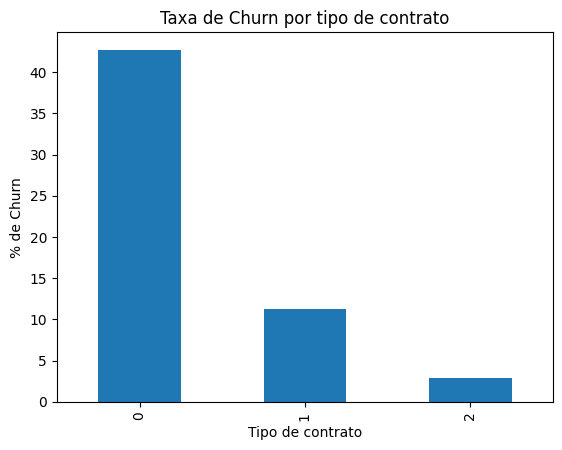

In [76]:
# Churn × Tipo de contrato
# Pergunta: contratos mês a mês têm maior churn que contratos anuais/bienais?

# Tabela cruzada normalizada (% por tipo de contrato)
tab_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(tab_contract)

# Renomeando colunas de 0/1 para No/Yes para facilitar leitura (opcional)
tab_contract = tab_contract.rename(columns={0: 'No', 1: 'Yes'})

# Plot da taxa de churn (coluna 'Yes')
tab_contract['Yes'].plot(kind='bar')
plt.ylabel('% de Churn')
plt.xlabel('Tipo de contrato')
plt.title('Taxa de Churn por tipo de contrato')
plt.show()


--- Proporção de Suporte Técnico por Status de Segurança Online (%) ---
TechSupport           No  No internet service  Yes
OnlineSecurity                                    
No                  73.0                  0.0 27.0
No internet service  0.0                100.0  0.0
Yes                 45.6                  0.0 54.4


<Figure size 700x500 with 0 Axes>

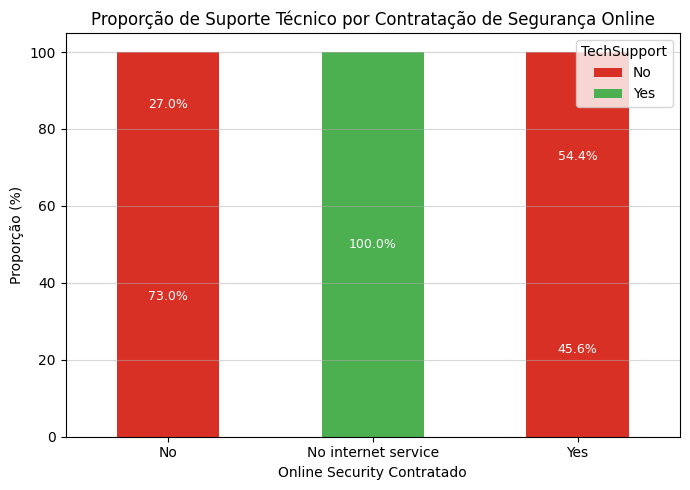


✅ Gráfico de barras empilhadas (ideal para esta proporção) salvo em 'analise_5_seguranca_suporte.png'.


In [77]:
def analise_pacote_seguranca_suporte(caminho_arquivo):
    df = pd.read_csv(caminho_arquivo)

    # 1. Pré-processamento e Limpeza
    col_x = 'OnlineSecurity'
    col_y = 'TechSupport'
    df = df.dropna(subset=[col_x, col_y])

    # 2. CÁLCULO DE PROPORÇÃO RESUMIDO
    # Cria a tabela de contingência e normaliza por índice (linha) para obter a % de TechSupport DENTRO de cada grupo OnlineSecurity.
    proporcao_servicos = pd.crosstab(df[col_x], df[col_y], normalize='index') * 100

    # IMPRIMIR O CÁLCULO DENTRO DO PRINT (USANDO TO_STRING)
    print("\n--- Proporção de Suporte Técnico por Status de Segurança Online (%) ---")
    print(proporcao_servicos.to_string(float_format='%.1f'))

    # VISUALIZAÇÃO (Melhor gráfico: Barras Empilhadas)
    plt.figure(figsize=(7, 5))

    ax = proporcao_servicos.plot(
        kind='bar', stacked=True,
        figsize=(7, 5),
        color=['#D93025', '#4CAF50'] # Vermelho para 'No', Verde para 'Yes'
    )

    plt.title('Proporção de Suporte Técnico por Contratação de Segurança Online')
    plt.xlabel('Online Security Contratado')
    plt.ylabel('Proporção (%)')
    plt.xticks(rotation=0)
    plt.legend(title='TechSupport', labels=['No', 'Yes'])
    plt.grid(axis='y', alpha=0.5)

    # Adicionar porcentagens nas barras
    for c in ax.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white')

    plt.tight_layout()
    plt.savefig('analise_5_seguranca_suporte.png')
    plt.show()

    print("\n✅ Gráfico de barras empilhadas (ideal para esta proporção) salvo em 'analise_5_seguranca_suporte.png'.")

analise_pacote_seguranca_suporte('churn.csv')


Média de permanência (tenure) por tipo de Internet:

InternetService
1    32.917959
0    32.889487
2    30.667763
Name: tenure, dtype: float64


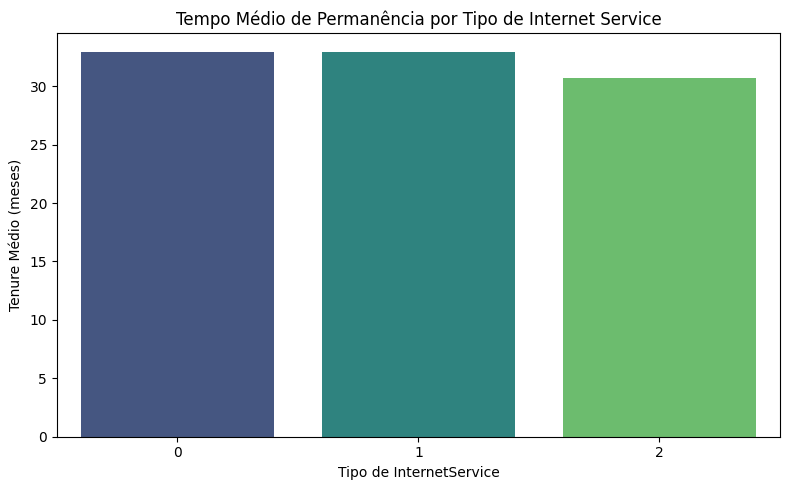

In [78]:
# Relação entre Tipo de Serviço de Internet e Tempo de Permanência (Tenure)
# Quais são os tipos de serviço de internet que possuem maior tempo de permanência?

# Calcular média de permanência por tipo de Internet
tenure_media = df.groupby("InternetService")["tenure"].mean().sort_values(ascending=False)
print("\nMédia de permanência (tenure) por tipo de Internet:\n")
print(tenure_media)

# Gráfico de barras
plt.figure(figsize=(8,5))
sns.barplot(x=tenure_media.index, y=tenure_media.values, palette="viridis")

plt.title("Tempo Médio de Permanência por Tipo de Internet Service")
plt.xlabel("Tipo de InternetService")
plt.ylabel("Tenure Médio (meses)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Pré-processamento e Divisão dos Dados

In [79]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# ----------------------------
# Padronização dos dados
# Importante para modelos sensíveis à escala (SVM, KNN, Regressão Logística)
# ----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# Divisão em treino (80%) e teste (20%)
# random_state garante reprodutibilidade
# ----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# ----------------------------
# Verificando o tamanho dos conjuntos
# ----------------------------
X_train.shape, X_test.shape

((5625, 19), (1407, 19))

## 8. Modelagem e Avaliação de Modelos




Logistic Regression: 0.7854
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

--------------------------------------------------
KNN: 0.7399
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.51      0.51      0.51       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407

--------------------------------------------------
SVC: 0.7910
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1033
           1       0.65      0.46      0.54       374

    accuracy                

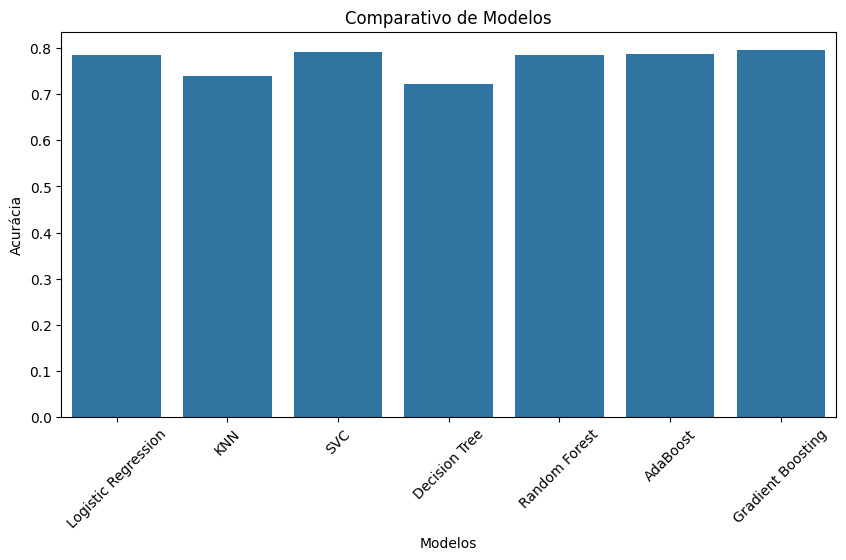

In [80]:
# Modelos a comparar
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVC': SVC(probability=True),  # probability=True necessário para curvas ROC e AUC
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = {}  # armazenará as acurácias dos modelos

# Loop que treina e avalia cada modelo
for name, model in models.items():
    model.fit(X_train, y_train)          # treinamento
    preds = model.predict(X_test)        # predições
    acc = accuracy_score(y_test, preds)  # cálculo da acurácia

    results[name] = acc  # salva resultado

    print(f'{name}: {acc:.4f}')
    print(classification_report(y_test, preds))
    print('-' * 50)

# Gráfico comparativo de desempenho
plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=45)
plt.title('Comparativo de Modelos')
plt.ylabel('Acurácia')
plt.xlabel('Modelos')
plt.show()

## 9. Avaliação Avançada (ROC-AUC e AUC-PR)


Logistic Regression - ROC-AUC: 0.8307 | PR-AUC: 0.6232
KNN - ROC-AUC: 0.7567 | PR-AUC: 0.5184
SVC - ROC-AUC: 0.7786 | PR-AUC: 0.6002
Decision Tree - ROC-AUC: 0.6534 | PR-AUC: 0.5568
Random Forest - ROC-AUC: 0.8164 | PR-AUC: 0.6261
AdaBoost - ROC-AUC: 0.8303 | PR-AUC: 0.6405
Gradient Boosting - ROC-AUC: 0.8356 | PR-AUC: 0.6474


<Figure size 800x600 with 0 Axes>

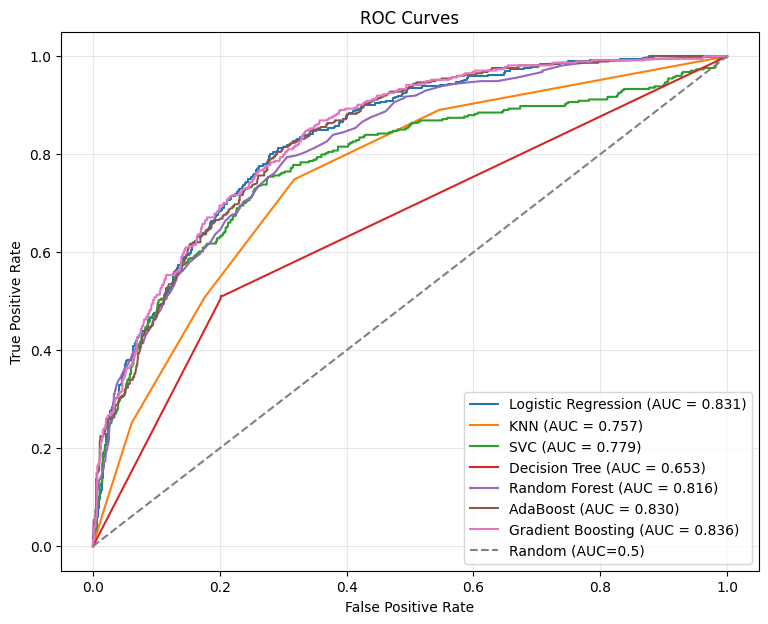

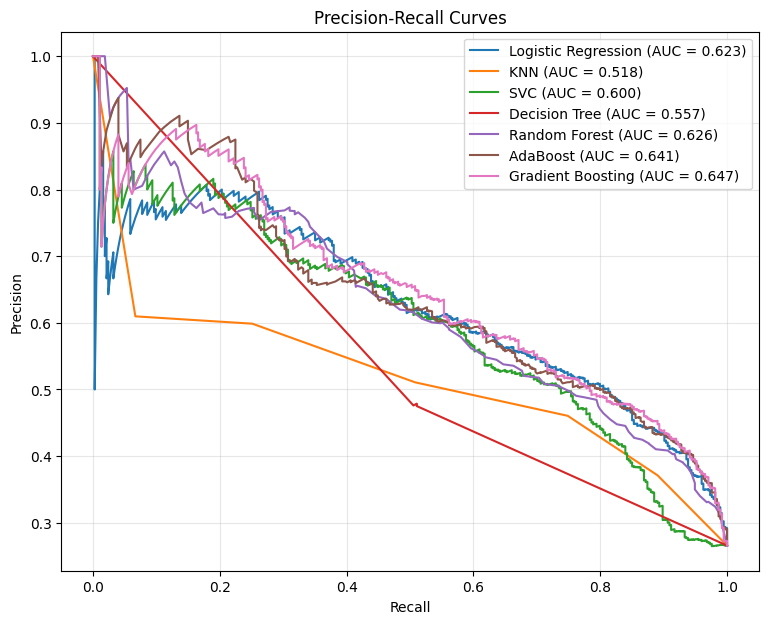

In [81]:

from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

# Dicionários para guardar resultados
roc_results = {}
pr_results = {}

plt.figure(figsize=(8,6))

# Loop para calcular ROC-AUC e armazenar curvas ROC
for name, model in models.items():
    # tenta obter uma pontuação contínua: probabilidade da classe positiva ou decision_function
    try:
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X_test)
        else:
            # se nenhum método disponível, ignora o modelo para ROC/PR
            print(f"{name}: não suporta predict_proba/decision_function — pulando ROC/PR.")
            continue
    except Exception as e:
        print(f"{name}: erro ao obter scores -> {e}")
        continue

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = roc_auc_score(y_test, y_scores)
    roc_results[name] = (fpr, tpr, roc_auc)

    # PR (Precision-Recall)
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)  # area under recall-precision curve
    pr_results[name] = (recall, precision, pr_auc)

    # Imprime os valores
    print(f"{name} - ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")

# --------------------------------------------------
# Plot agregado: Curvas ROC
# --------------------------------------------------
plt.figure(figsize=(9,7))
for name, (fpr, tpr, roc_auc) in roc_results.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], '--', color='gray', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# --------------------------------------------------
# Plot agregado: Curvas Precision-Recall
# --------------------------------------------------
plt.figure(figsize=(9,7))
for name, (recall, precision, pr_auc) in pr_results.items():
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

## 10. Tuning de Hiperparâmetros

In [82]:
# 10. Tuning de Hiperparâmetros (Obrigatório)
# Exemplo: GridSearchCV e RandomizedSearchCV no RandomForestClassifier
# Inclui avaliação do melhor modelo no conjunto de teste e salvamento do modelo.

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import time

# --------------------------
# 1) Grid Search (exemplo pequeno)
# --------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',    # otimizar F1 (balanceia precision/recall)
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid.fit(X_train, y_train)
end = time.time()

print(f"GridSearch concluído em {(end-start):.1f} segundos")
print("Melhores hiperparâmetros (GridSearch):", grid.best_params_)

best_rf_grid = grid.best_estimator_

# Avaliação no conjunto de teste
preds_grid = best_rf_grid.predict(X_test)
proba_grid = best_rf_grid.predict_proba(X_test)[:,1] if hasattr(best_rf_grid, "predict_proba") else None

print("\nRelatório de Classificação (GridSearch):")
print(classification_report(y_test, preds_grid))
print("Matriz de Confusão (GridSearch):")
print(confusion_matrix(y_test, preds_grid))
if proba_grid is not None:
    print("ROC-AUC (GridSearch):", roc_auc_score(y_test, proba_grid))


# --------------------------
# 2) Randomized Search (mais eficiente para espaços grandes)
# --------------------------
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [5, 10, 15, None],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rand = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,          # número de combinações a testar
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start = time.time()
rand.fit(X_train, y_train)
end = time.time()

print(f"\nRandomizedSearch concluído em {(end-start):.1f} segundos")
print("Melhores hiperparâmetros (RandomizedSearch):", rand.best_params_)

best_rf_rand = rand.best_estimator_

# Avaliação no conjunto de teste
preds_rand = best_rf_rand.predict(X_test)
proba_rand = best_rf_rand.predict_proba(X_test)[:,1] if hasattr(best_rf_rand, "predict_proba") else None

print("\nRelatório de Classificação (RandomizedSearch):")
print(classification_report(y_test, preds_rand))
print("Matriz de Confusão (RandomizedSearch):")
print(confusion_matrix(y_test, preds_rand))
if proba_rand is not None:
    print("ROC-AUC (RandomizedSearch):", roc_auc_score(y_test, proba_rand))


# --------------------------
# 3) Escolhendo o melhor entre os dois (por F1 ou ROC-AUC)
# --------------------------
# Aqui escolhemos pelo F1 do conjunto de teste
from sklearn.metrics import f1_score

f1_grid = f1_score(y_test, preds_grid)
f1_rand = f1_score(y_test, preds_rand)

if f1_rand >= f1_grid:
    best_model = best_rf_rand
    print(f"\nModelo final escolhido: RandomizedSearch (F1: {f1_rand:.4f} >= GridSearch F1: {f1_grid:.4f})")
else:
    best_model = best_rf_grid
    print(f"\nModelo final escolhido: GridSearch (F1: {f1_grid:.4f} > RandomizedSearch F1: {f1_rand:.4f})")

# Salvar o modelo final em disco
joblib.dump(best_model, "best_random_forest.pkl")
print("Modelo salvo em 'best_random_forest.pkl'")

# Exibir hiperparâmetros finais
print("\nHiperparâmetros do modelo final:")
print(best_model.get_params())


Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearch concluído em 28.2 segundos
Melhores hiperparâmetros (GridSearch): {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Relatório de Classificação (GridSearch):
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Matriz de Confusão (GridSearch):
[[933 100]
 [192 182]]
ROC-AUC (GridSearch): 0.8264672233409777
Fitting 5 folds for each of 20 candidates, totalling 100 fits

RandomizedSearch concluído em 96.1 segundos
Melhores hiperparâmetros (RandomizedSearch): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 152}

Relatório de Classificação (RandomizedSearch):
              precision    recall  f1-score   s